In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print("사용할 PyTorch 버전:", torch.__version__,' Device:', DEVICE)

BATCH_SIZE = 32
EPOCHS = 10

사용할 PyTorch 버전: 2.13.0+cu130  Device: cpu


/home/kim/Desktop/YoungJae/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
train_dataset = datasets.MNIST(root = "./data/MNIST",
                               train = True,
                               download = True,
                               transform = transforms.ToTensor())

test_dataset = datasets.MNIST(root = "./data/MNIST",
                              train = False,
                              transform = transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = BATCH_SIZE,
                                           shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = BATCH_SIZE,
                                          shuffle = False)

100.0%
100.0%
100.0%
100.0%


In [5]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


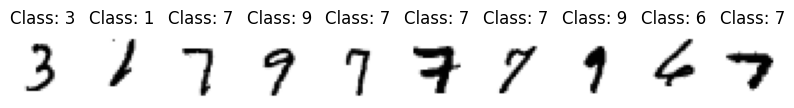

In [6]:
pltsize = 1
plt.figure(figsize=(10 * pltsize, pltsize)) #10개 plot하기 위한 figure 크기 설정

for i in range(10):
    plt.subplot(1, 10, i + 1) # plot.subplot(rows, columns, index)
    plt.axis('off')
    plt.imshow(X_train[i, :, :, :].numpy().reshape(28, 28), cmap = "gray_r")
    plt.title('Class: ' + str(y_train[i].item()))

In [7]:
class Net(nn.Module): # nn.Module은 모든 neural network의 base class라고 한다. 
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        
    def forward(self,x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = F.sigmoid(x)
        x = self.fc2(x)
        x = F.sigmoid(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)
        return x

In [8]:
model = Net().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
criterion = nn.CrossEntropyLoss()

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [9]:
def train(model, train_loader, optimizer, log_interval):
    model.train()
    for batch_idx, (image, label) in enumerate(train_loader):
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        
        if batch_idx % log_interval == 0:
            print("Train epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}".format(
                epoch, batch_idx * len(image),
                len(train_loader.dataset), 100. * batch_idx / len(train_loader),
                loss.item()))

In [10]:
def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    
    with torch.no_grad():
        for image, label in test_loader:
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim=True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= (len(test_loader.dataset)/ BATCH_SIZE)
    test_accuracy = 100. * correct/len(test_loader.dataset)
    return test_loss, test_accuracy

In [ ]:
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer, log_interval = 200)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} %\n".format(
        epoch, test_loss, test_accuracy))

Train epoch: 1 [0/60000 (0%)]	Train Loss: 2.385381
Train epoch: 1 [6400/60000 (11%)]	Train Loss: 2.216511
Train epoch: 1 [12800/60000 (21%)]	Train Loss: 2.315102
Train epoch: 1 [19200/60000 (32%)]	Train Loss: 2.310266
Train epoch: 1 [25600/60000 (43%)]	Train Loss: 2.329960
Train epoch: 1 [32000/60000 (53%)]	Train Loss: 2.291680
Train epoch: 1 [38400/60000 (64%)]	Train Loss: 2.218251
Train epoch: 1 [44800/60000 (75%)]	Train Loss: 2.258855
Train epoch: 1 [51200/60000 (85%)]	Train Loss: 2.271147
Train epoch: 1 [57600/60000 (96%)]	Train Loss: 2.214391

[EPOCH: 1], 	Test Loss: 2.2375, 	Test Accuracy: 34.16 %

Train epoch: 2 [0/60000 (0%)]	Train Loss: 2.219007
Train epoch: 2 [6400/60000 (11%)]	Train Loss: 2.258939
Train epoch: 2 [12800/60000 (21%)]	Train Loss: 2.201686
Train epoch: 2 [19200/60000 (32%)]	Train Loss: 2.019431
Train epoch: 2 [25600/60000 (43%)]	Train Loss: 2.066699
Train epoch: 2 [32000/60000 (53%)]	Train Loss: 1.808281
Train epoch: 2 [38400/60000 (64%)]	Train Loss: 1.730420
Tr

In [ ]:
# 최종 검증: 학습이 끝난 모델의 테스트 데이터 성능을 다시 확인합니다.
final_test_loss, final_test_accuracy = evaluate(model, test_loader)

print(f"최종 검증 손실: {final_test_loss:.4f}")
print(f"최종 검증 정확도: {final_test_accuracy:.2f}%")

In [ ]:
# 숫자별로 얼마나 맞고 틀렸는지 확인하기 위한 혼동 행렬입니다.
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for image, label in test_loader:
        image = image.to(DEVICE)
        output = model(image)
        prediction = output.argmax(dim=1).cpu()

        all_labels.append(label)
        all_predictions.append(prediction)

all_labels = torch.cat(all_labels)
all_predictions = torch.cat(all_predictions)

confusion_matrix = torch.zeros(10, 10, dtype=torch.int64)
for label, prediction in zip(all_labels, all_predictions):
    confusion_matrix[int(label), int(prediction)] += 1

plt.figure(figsize=(8, 7))
plt.imshow(confusion_matrix.numpy(), cmap='Blues')
plt.title('MNIST Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()

max_count = confusion_matrix.max().item()
for row in range(10):
    for col in range(10):
        count = confusion_matrix[row, col].item()
        text_color = 'white' if count > max_count * 0.5 else 'black'
        plt.text(col, row, str(count), ha='center', va='center', color=text_color)

plt.tight_layout()
plt.show()

In [ ]:
# 테스트 이미지 몇 장을 실제 정답과 모델 예측으로 비교합니다.
sample_images, sample_labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    sample_output = model(sample_images.to(DEVICE))
    sample_predictions = sample_output.argmax(dim=1).cpu()

plt.figure(figsize=(12, 7))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.axis('off')
    plt.imshow(sample_images[i].numpy().reshape(28, 28), cmap='gray_r')

    true_label = sample_labels[i].item()
    predicted_label = sample_predictions[i].item()
    title_color = 'green' if true_label == predicted_label else 'red'
    plt.title(f'Pred: {predicted_label}\nTrue: {true_label}', color=title_color)

plt.tight_layout()
plt.show()